In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import files


In [20]:
#Uncomment this cell to upload the file. It has been commeted out as the colab cell takes up 50% of the github space when uploaded as a notebook
"""
files.upload()
"""

'\nfiles.upload()\n'

In [16]:

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [2]:
def save_plot(filename):
    """Save a matplotlib figure as a 600 DPI .eps file and trigger a Colab download."""
    path = f"{filename}.eps"
    plt.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    files.download(path)
    print(f"Saved and downloaded: {path}")

In [ ]:
#Task 1: Dataset EXploration

df=pd.read_excel("Perceptron.xlsx")


print(df.head())
print()
print("Dimensions: ", df.shape)
print()
print("Missing values per column:")
df.isnull().sum()



   Variance  Skewness  Curtosis  Entropy  Target Class
0   3.62160    8.6661   -2.8073 -0.44699             0
1   4.54590    8.1674   -2.4586 -1.46210             0
2   3.86600   -2.6383    1.9242  0.10645             0
3   3.45660    9.5228   -4.0112 -3.59440             0
4   0.32924   -4.4552    4.5718 -0.98880             0

Dimensions:  (1372, 5)

Missing values per column:


,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Target Class,0


In [ ]:
print("General statistics: ")
df.describe()

General statistics: 


,Variance,Skewness,Curtosis,Entropy,Target Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
#Task 2: EDA

feature_cols = ['Variance', 'Skewness', 'Curtosis', 'Entropy']
target_col = 'Target Class'

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: feature_histograms.eps


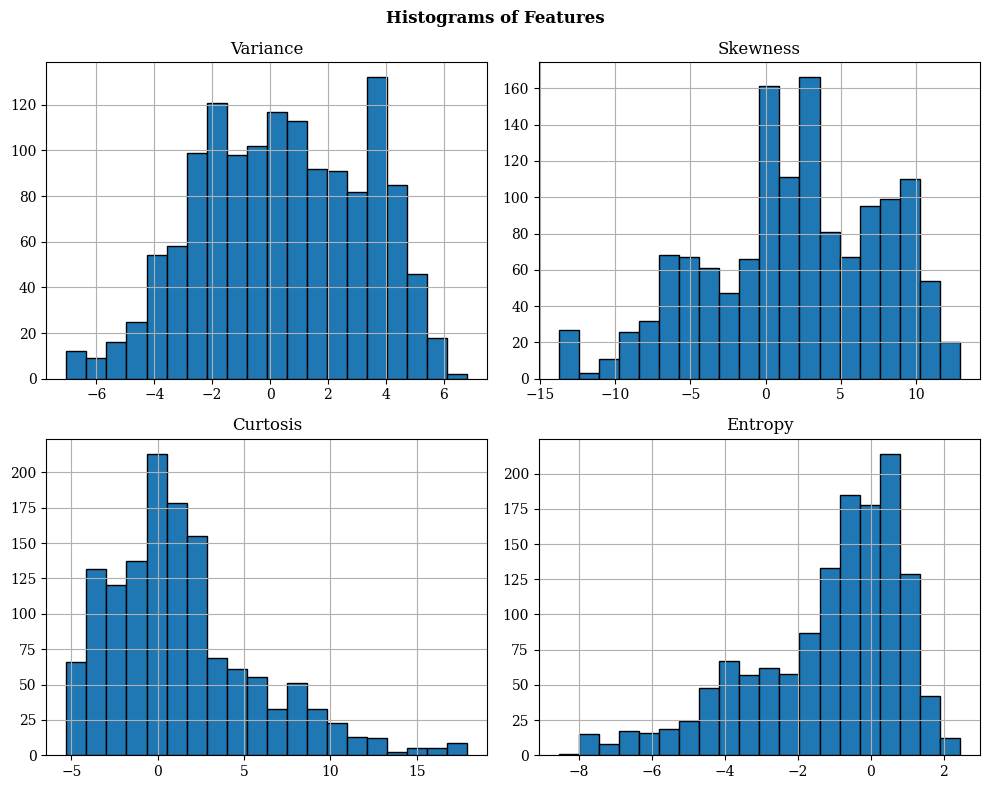

In [ ]:
#Histogram
df[feature_cols].hist(figsize=(10, 8), bins=20, edgecolor='black')
plt.suptitle("Histograms of Features", fontweight="bold")
plt.tight_layout()
save_plot("feature_histograms")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: corr_heatmap.eps


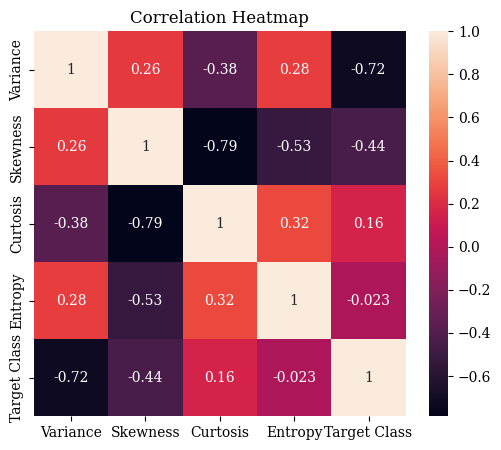

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
save_plot("corr_heatmap")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: scatter_plot.eps


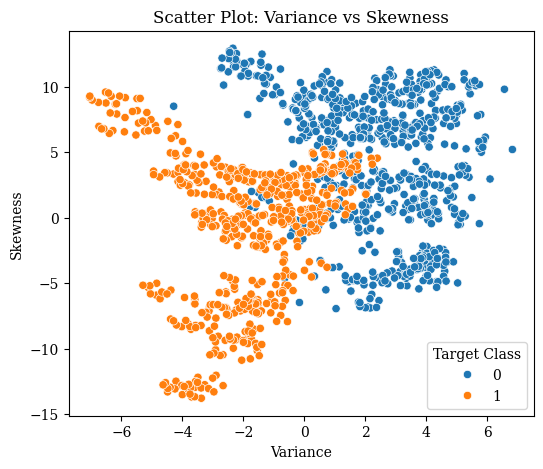

In [ ]:
#Scatter plot for variance vs skewness
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='Variance', y='Skewness', hue=target_col)
plt.title("Scatter Plot: Variance vs Skewness")
save_plot("scatter_plot")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: feature_boxplot.eps


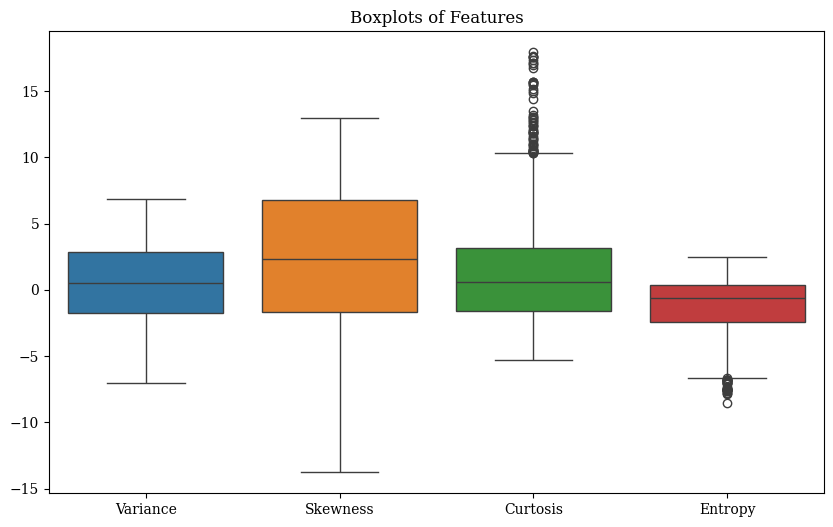

In [ ]:
#Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[feature_cols])
plt.title("Boxplots of Features")
save_plot("feature_boxplot")
plt.show()

In [ ]:
#Task 3: Data preprocessing

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

x=df[feature_cols]
y=df[target_col]

scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled_df=pd.DataFrame(x_scaled, columns=feature_cols)

#Train test split
x_train, x_test, y_train, y_test=train_test_split(x_scaled_df, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)

(1097, 4)
(275, 4)


In [ ]:
#Task 4: Perceptron implementation

class Perceptron:
    def __init__(self, n_features, learning_rate=0.01):
        #Weight initialization
        self.weights = np.zeros(n_features)

        # Bias Initialization
        self.bias = 0.0

        self.lr = learning_rate

    #Step activation
    def step_function(self, z):
        return np.where(z >= 0, 1, 0)

    #Forward propagation
    def forward(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.step_function(z)

    #Perceptron Learning Rule
    def update_weights(self, x_i, y_true, y_pred):
        error = y_true - y_pred
        self.weights += self.lr * error * x_i
        self.bias += self.lr * error
        return error

In [ ]:
#Task 5: Model training

# Convert to numpy arrays (in case they are still DataFrames/Series)
X_train_np = x_train.to_numpy() if hasattr(x_train, "to_numpy") else x_train
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else y_train

X_test_np = x_test.to_numpy() if hasattr(x_test, "to_numpy") else x_test
y_test_np = y_test.to_numpy() if hasattr(y_test, "to_numpy") else y_test

n_features = X_train_np.shape[1]
n_epochs = 20

# Initialize perceptron
model = Perceptron(n_features=n_features, learning_rate=0.01)

# ---- Storage for later plotting in Task 7 ----
error_history = []
weight_history = []
bias_history = []

print("Initial Weights:", model.weights)
print("Initial Bias:", model.bias)
print("-" * 60)

for epoch in range(1, n_epochs + 1):
    misclassified_count = 0

    for x_i, y_true in zip(X_train_np, y_train_np):
        y_pred = model.forward(x_i.reshape(1, -1))[0]

        if y_pred != y_true:
            misclassified_count += 1
            model.update_weights(x_i, y_true, y_pred)

    # ---- Store history for Task 7 plots ----
    error_history.append(misclassified_count)
    weight_history.append(model.weights.copy())
    bias_history.append(model.bias)

    # ---- Display epoch details ----
    print(f"Epoch {epoch}")
    print(f"  Misclassified Samples : {misclassified_count}")
    print(f"  Updated Weights       : {model.weights}")
    print(f"  Updated Bias          : {model.bias}")
    print("-" * 60)

    # Stop early if perfectly classified
    if misclassified_count == 0:
        print(f"Converged at epoch {epoch}. Stopping training.")
        break

weight_history = np.array(weight_history)   # shape: (epochs_run, n_features)
bias_history = np.array(bias_history)

Initial Weights: [0. 0. 0. 0.]
Initial Bias: 0.0
------------------------------------------------------------
Epoch 1
  Misclassified Samples : 47
  Updated Weights       : [-0.07253688 -0.06486266 -0.06445982  0.00019858]
  Updated Bias          : -0.03
------------------------------------------------------------
Epoch 2
  Misclassified Samples : 26
  Updated Weights       : [-0.08217015 -0.09380199 -0.05149354 -0.00518242]
  Updated Bias          : -0.03
------------------------------------------------------------
Epoch 3
  Misclassified Samples : 34
  Updated Weights       : [-0.09467641 -0.09140031 -0.08905542 -0.00956468]
  Updated Bias          : -0.05
------------------------------------------------------------
Epoch 4
  Misclassified Samples : 23
  Updated Weights       : [-0.11074483 -0.09580878 -0.10630688 -0.01312422]
  Updated Bias          : -0.04
------------------------------------------------------------
Epoch 5
  Misclassified Samples : 27
  Updated Weights       : [-0

In [ ]:
#Task 6: Model evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predictions on test set
y_pred_test = model.forward(X_test_np)


# ---- Optional cross-check with scikit-learn
print("Accuracy :", accuracy_score(y_test_np, y_pred_test))
print("Precision:", precision_score(y_test_np, y_pred_test))
print("Recall :", recall_score(y_test_np, y_pred_test))
print("F1 score :", f1_score(y_test_np, y_pred_test))

Accuracy : 0.9636363636363636
Precision: 1.0
Recall : 0.9212598425196851
F1 score : 0.9590163934426229


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: conf_matrix.eps


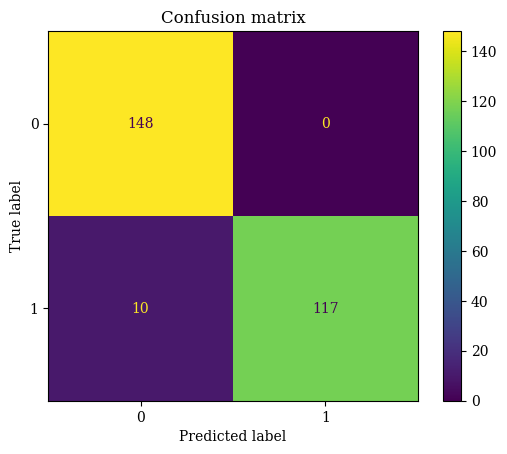

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test_np, y_pred_test))
disp.plot()
plt.title("Confusion matrix")
save_plot("conf_matrix")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: train_error_vs_epoch.eps


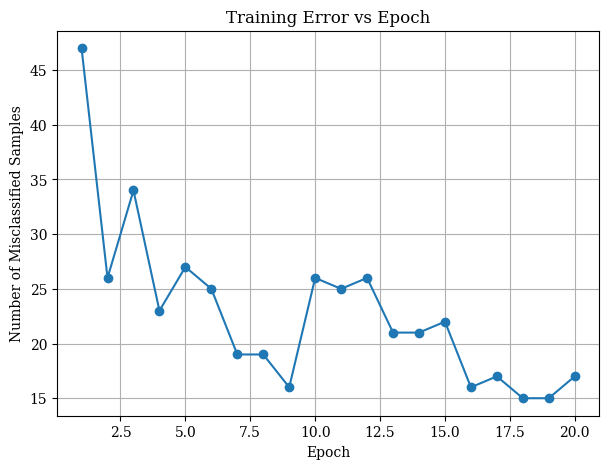

In [ ]:
#Task 7: Important Plots

# 4. Training Error vs Epoch
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(error_history) + 1), error_history, marker='o')
plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassified Samples")
plt.grid(True)
save_plot("train_error_vs_epoch")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: weight_evol.eps


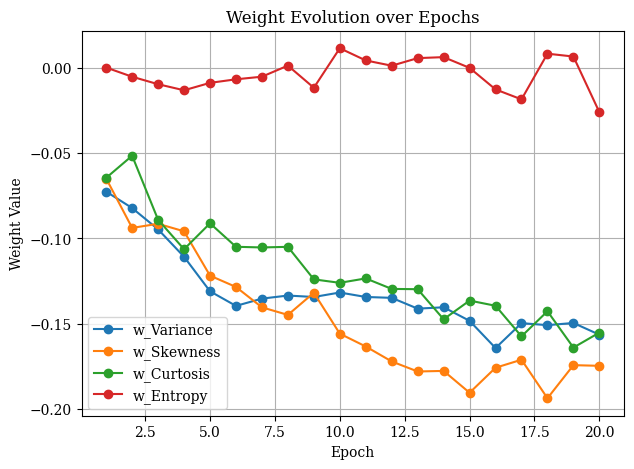

In [ ]:
plt.figure(figsize=(7, 5))
for i, col in enumerate(feature_cols):
    plt.plot(range(1, len(weight_history) + 1), weight_history[:, i], marker='o', label=f'w_{col}')
plt.title("Weight Evolution over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)
save_plot("weight_evol")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: bias_evol.eps


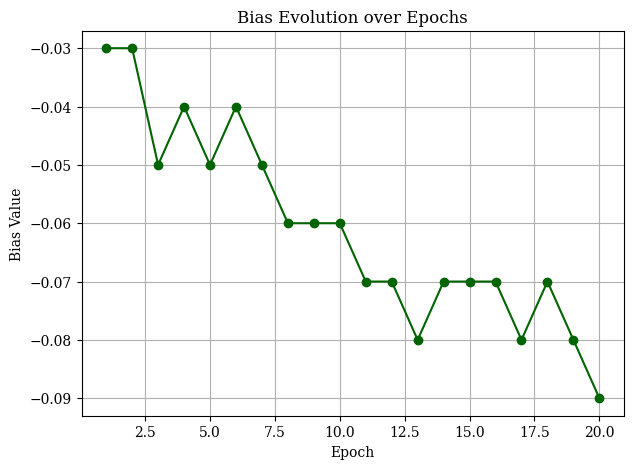

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(bias_history) + 1), bias_history, marker='o', color='darkgreen')
plt.title("Bias Evolution over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.grid(True)
save_plot("bias_evol")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: lr_comparison.eps


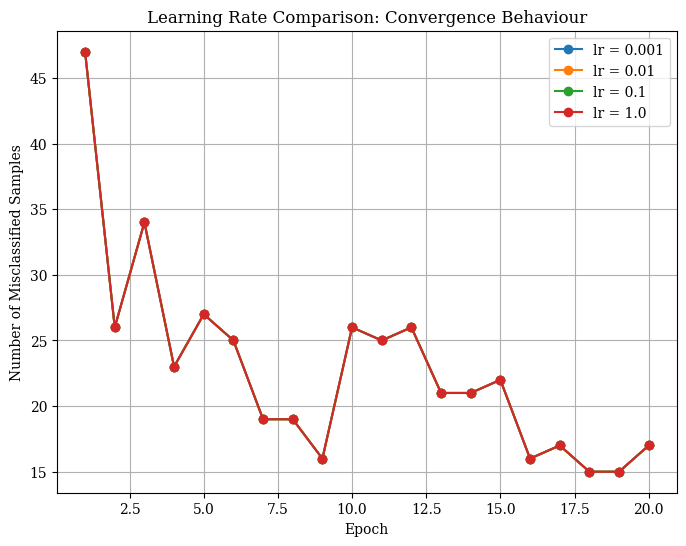

In [ ]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
lr_error_histories = {}

for lr in learning_rates:
    temp_model = Perceptron(n_features=n_features, learning_rate=lr)
    temp_error_history = []

    for epoch in range(n_epochs):
        misclassified_count = 0
        for x_i, y_true in zip(X_train_np, y_train_np):
            y_pred = temp_model.forward(x_i.reshape(1, -1))[0]
            if y_pred != y_true:
                misclassified_count += 1
                temp_model.update_weights(x_i, y_true, y_pred)
        temp_error_history.append(misclassified_count)

    lr_error_histories[lr] = temp_error_history

plt.figure(figsize=(8, 6))
for lr, errors in lr_error_histories.items():
    plt.plot(range(1, len(errors) + 1), errors, marker='o', label=f'lr = {lr}')
plt.title("Learning Rate Comparison: Convergence Behaviour")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassified Samples")
plt.legend()
plt.grid(True)
save_plot("lr_comparison")
plt.show()

In [3]:
#Additional task: Training NOT, AND and OR gates
class Perceptron:
    def __init__(self, input_size, lr=1):
        self.W = np.zeros(input_size + 1)
        self.lr = lr

    def predict(self, x):
        z = self.W.dot(x)
        return 1 if z >= 0 else 0

    def plot_boundary(self, X, d, gate_name, epoch, update_count):
        plt.figure(figsize=(6, 4))
        plt.title(f"{gate_name} Gate - Epoch {epoch}, Update {update_count}\nWeights: {self.W}")

        # 2-Input Gates (AND, OR)
        if X.shape[1] == 3:
            for i in range(X.shape[0]):
                color = 'blue' if d[i] == 1 else 'red'
                marker = '+' if d[i] == 1 else 'o'
                plt.scatter(X[i][1], X[i][2], c=color, marker=marker, s=150)

            if self.W[2] != 0:
                x1_vals = np.array([-0.5, 1.5])
                x2_vals = -(self.W[1] / self.W[2]) * x1_vals - (self.W[0] / self.W[2])
                plt.plot(x1_vals, x2_vals, color='black', linestyle='--')
            elif self.W[1] != 0:
                plt.axvline(x=-self.W[0]/self.W[1], color='black', linestyle='--')

            plt.xlim(-0.5, 1.5)
            plt.ylim(-0.5, 1.5)
            plt.xlabel("Input 1")
            plt.ylabel("Input 2")

        # 1-Input Gate (NOT)
        elif X.shape[1] == 2:
            for i in range(X.shape[0]):
                color = 'blue' if d[i] == 1 else 'red'
                marker = '+' if d[i] == 1 else 'o'
                plt.scatter(X[i][1], 0, c=color, marker=marker, s=150)

            if self.W[1] != 0:
                plt.axvline(x=-self.W[0]/self.W[1], color='black', linestyle='--')

            plt.xlim(-0.5, 1.5)
            plt.ylim(-0.5, 0.5)
            plt.xlabel("Input 1")
            plt.yticks([])

        plt.grid(True)

        # Save and download before showing
        filename = f"{gate_name}_Epoch{epoch}_Update{update_count}"
        save_plot(filename)

        plt.show(block=False)
        plt.pause(1.5)
        plt.close()

    def train(self, X, d, gate_name, epochs=10):
        print(f"\nTraining {gate_name} Gate...")
        X_biased = np.insert(X, 0, 1, axis=1)
        update_count = 0

        for epoch in range(1, epochs + 1):
            errors = 0
            for i in range(X_biased.shape[0]):
                x_i = X_biased[i]
                y = self.predict(x_i)
                error = d[i] - y

                if error != 0:
                    self.W = self.W + self.lr * error * x_i
                    errors += 1
                    update_count += 1

                    print(f"Update {update_count} (Epoch {epoch}): "
                          f"Point {X[i]} -> Target {d[i]}, "
                          f"Predicted {y} | New Weights: {self.W}")

                    self.plot_boundary(X_biased, d, gate_name, epoch, update_count)

            if errors == 0:
                print(f"✅ {gate_name} Gate converged in {epoch} epochs!")
                break

In [8]:
# OR Gate Data
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
d_or = np.array([0, 1, 1, 1])

# AND Gate Data
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
d_and = np.array([0, 0, 0, 1])

# NOT Gate Data
X_not = np.array([[0], [1]])
d_not = np.array([1, 0])


Training OR Gate...
Update 1 (Epoch 1): Point [0 0] -> Target 0, Predicted 1 | New Weights: [-1.  0.  0.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: OR_Epoch1_Update1.eps


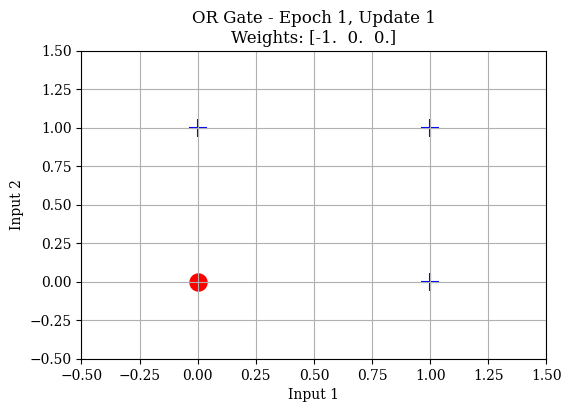

Update 2 (Epoch 1): Point [0 1] -> Target 1, Predicted 0 | New Weights: [0. 0. 1.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: OR_Epoch1_Update2.eps


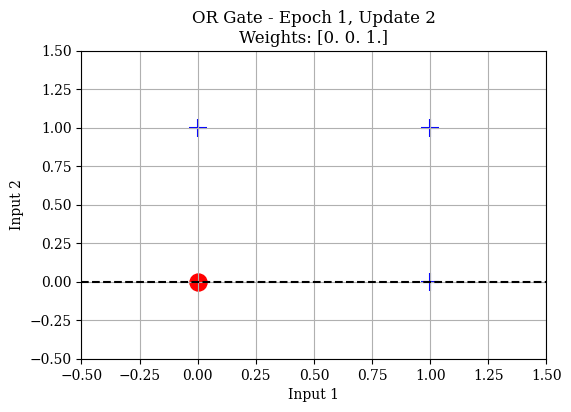

Update 3 (Epoch 2): Point [0 0] -> Target 0, Predicted 1 | New Weights: [-1.  0.  1.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: OR_Epoch2_Update3.eps


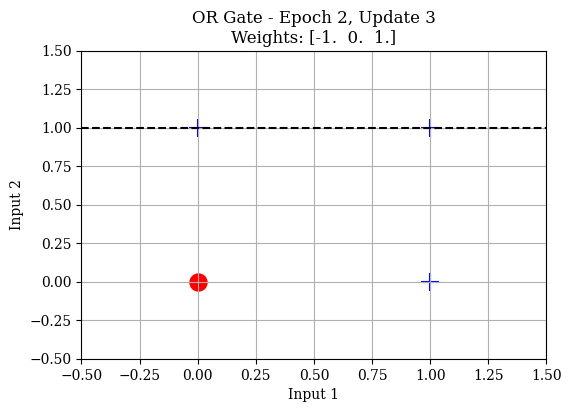

Update 4 (Epoch 2): Point [1 0] -> Target 1, Predicted 0 | New Weights: [0. 1. 1.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: OR_Epoch2_Update4.eps


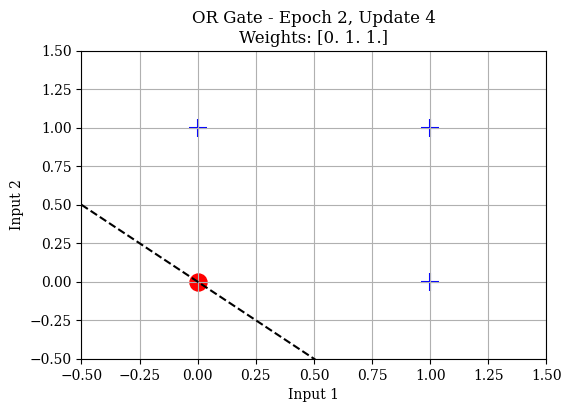

Update 5 (Epoch 3): Point [0 0] -> Target 0, Predicted 1 | New Weights: [-1.  1.  1.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: OR_Epoch3_Update5.eps


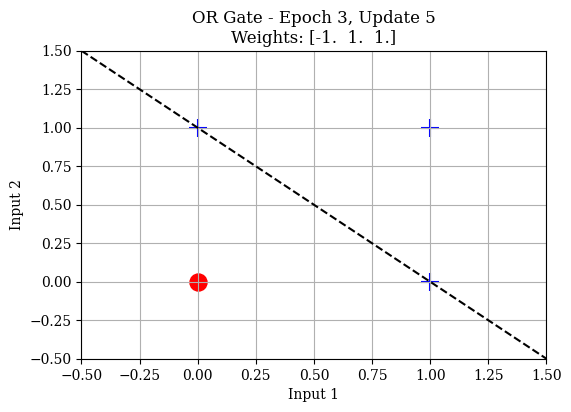

✅ OR Gate converged in 4 epochs!


In [17]:
p_or = Perceptron(input_size=2, lr=1)
p_or.train(X_or, d_or, "OR")


Training AND Gate...
Update 1 (Epoch 1): Point [0 0] -> Target 0, Predicted 1 | New Weights: [-1.  0.  0.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: AND_Epoch1_Update1.eps


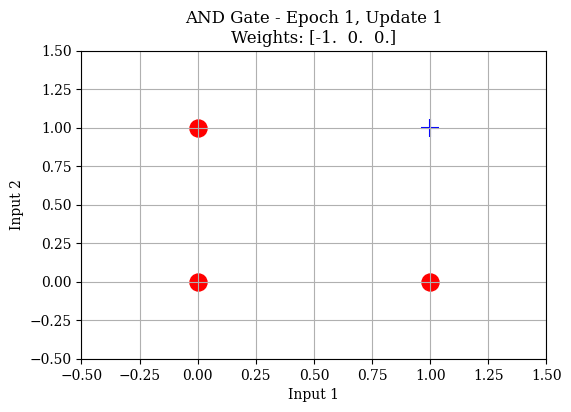

Update 2 (Epoch 1): Point [1 1] -> Target 1, Predicted 0 | New Weights: [0. 1. 1.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: AND_Epoch1_Update2.eps


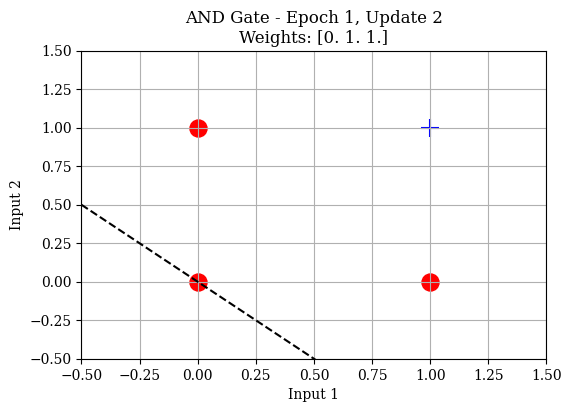

Update 3 (Epoch 2): Point [0 0] -> Target 0, Predicted 1 | New Weights: [-1.  1.  1.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: AND_Epoch2_Update3.eps


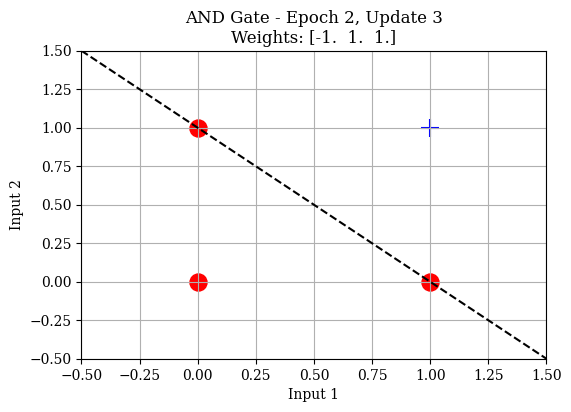

Update 4 (Epoch 2): Point [0 1] -> Target 0, Predicted 1 | New Weights: [-2.  1.  0.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: AND_Epoch2_Update4.eps


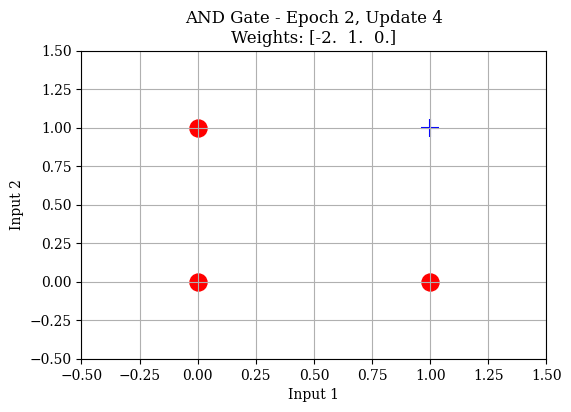

Update 5 (Epoch 2): Point [1 1] -> Target 1, Predicted 0 | New Weights: [-1.  2.  1.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: AND_Epoch2_Update5.eps


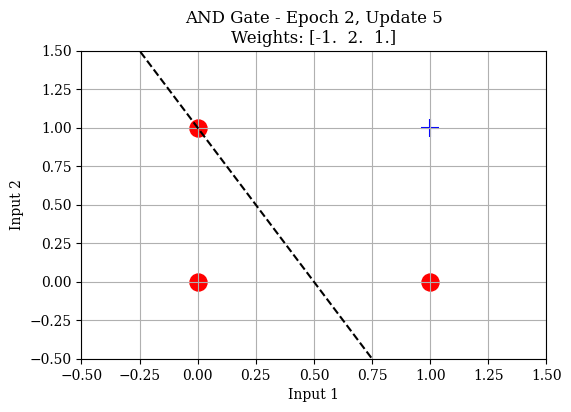

Update 6 (Epoch 3): Point [0 1] -> Target 0, Predicted 1 | New Weights: [-2.  2.  0.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: AND_Epoch3_Update6.eps


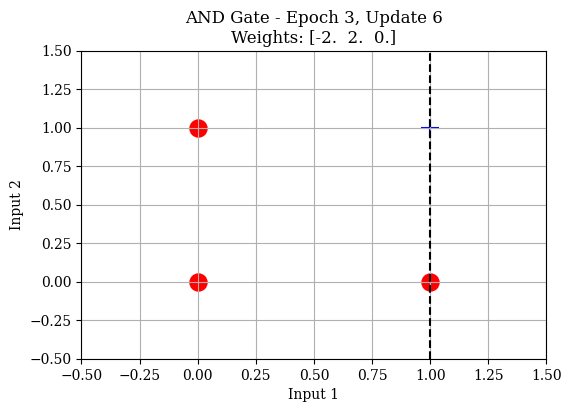

Update 7 (Epoch 3): Point [1 0] -> Target 0, Predicted 1 | New Weights: [-3.  1.  0.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: AND_Epoch3_Update7.eps


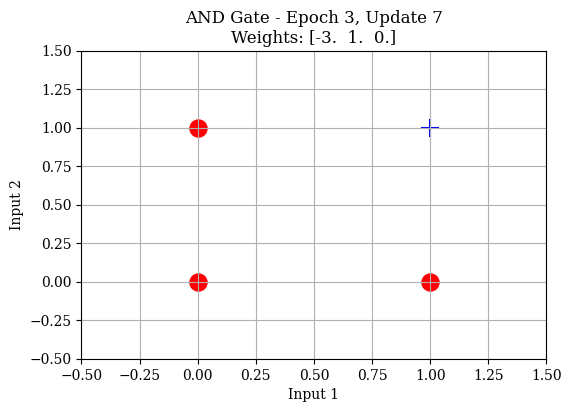

Update 8 (Epoch 3): Point [1 1] -> Target 1, Predicted 0 | New Weights: [-2.  2.  1.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: AND_Epoch3_Update8.eps


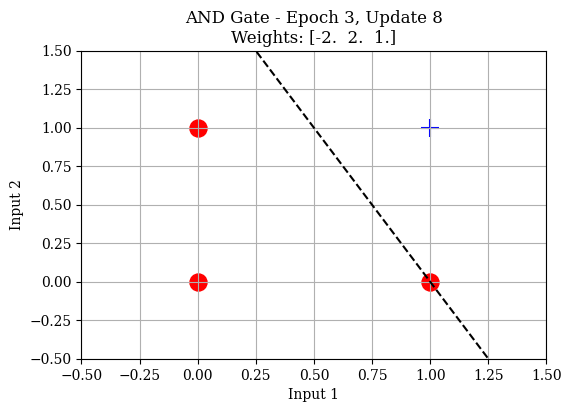

Update 9 (Epoch 4): Point [1 0] -> Target 0, Predicted 1 | New Weights: [-3.  1.  1.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: AND_Epoch4_Update9.eps


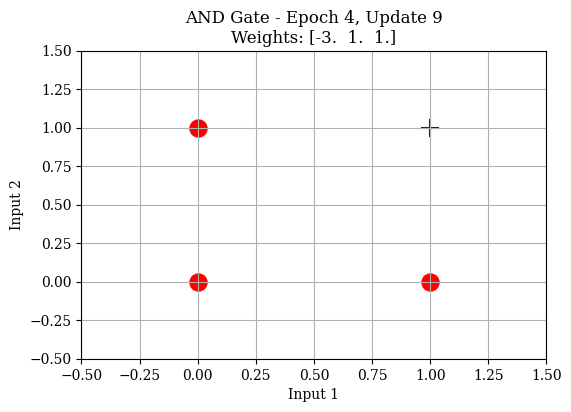

Update 10 (Epoch 4): Point [1 1] -> Target 1, Predicted 0 | New Weights: [-2.  2.  2.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: AND_Epoch4_Update10.eps


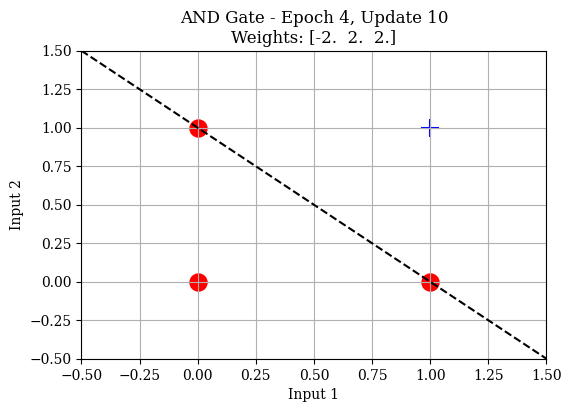

Update 11 (Epoch 5): Point [0 1] -> Target 0, Predicted 1 | New Weights: [-3.  2.  1.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: AND_Epoch5_Update11.eps


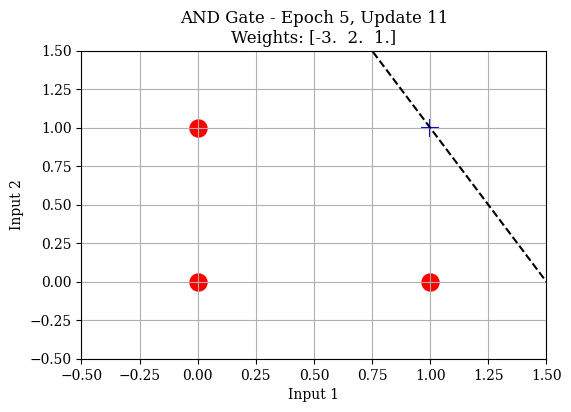

✅ AND Gate converged in 6 epochs!


In [18]:
p_and = Perceptron(input_size=2, lr=1)
p_and.train(X_and, d_and, "AND")


Training NOT Gate...
Update 1 (Epoch 1): Point [1] -> Target 0, Predicted 1 | New Weights: [-1. -1.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: NOT_Epoch1_Update1.eps


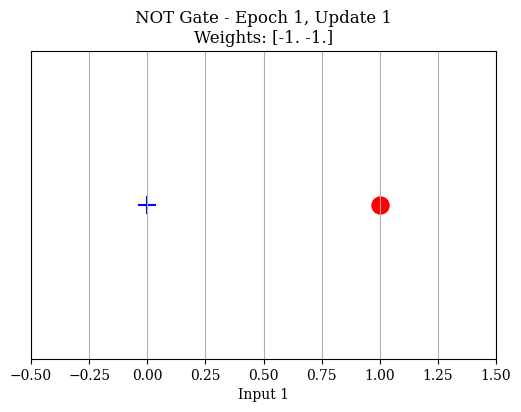

Update 2 (Epoch 2): Point [0] -> Target 1, Predicted 0 | New Weights: [ 0. -1.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: NOT_Epoch2_Update2.eps


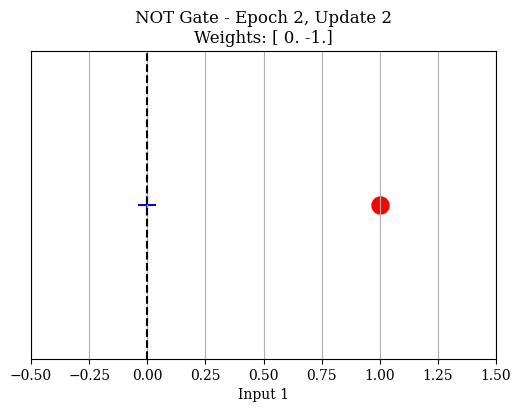

✅ NOT Gate converged in 3 epochs!


In [19]:
p_not = Perceptron(input_size=1, lr=1)
p_not.train(X_not, d_not, "NOT")